**Part 15 — Python / NumPy** should now convert the higher-dimensional mathematics from Part 14 into actual NumPy operations.

The purpose is **not** to teach NumPy syntax again—we already covered that in the Python/NumPy portion of the curriculum. Here, NumPy is being used as an ML tool to make the mathematics executable.

The core mapping will be:

$$
\vec{x}
\leftrightarrow
\texttt{numpy array}
$$

$$
\vec{w}
\leftrightarrow
\texttt{numpy array}
$$

$$
\vec{w}^{\,T}\vec{x}
\leftrightarrow
\texttt{np.dot(w, x)}
$$

$$
\|\vec{w}\|
\leftrightarrow
\texttt{np.linalg.norm(w)}
$$

and ultimately:

$$
\boxed{
\gamma_i=
\frac{
y_i\left(\vec{w}^{\,T}\vec{x}_i+b\right)
}{
\|\vec{w}\|
}
}
$$

Below is the notebook-ready version.

# Chapter 4 — Part 15

# Python / NumPy

> **Goal:**  
> Translate the mathematical expressions from this chapter into NumPy code.

Throughout this chapter we have worked with:

$$
\vec{x}
$$

$$
\vec{w}
$$

and:

$$
b
$$

and used them to construct a linear classifier:

$$
\boxed{
\vec{w}^{\,T}\vec{x}+b
}
$$

We have also seen that the geometric margin for a labeled example is:

$$
\boxed{
\gamma_i
=
\frac{
y_i
\left(
\vec{w}^{\,T}\vec{x}_i+b
\right)
}{
\|\vec{w}\|
}
}
$$

Now we will implement these mathematical operations using NumPy.

The important goal is to understand the correspondence:

$$
\boxed{
\text{Mathematics}
\longleftrightarrow
\text{NumPy}
}
$$

## 1. Representing a Vector in NumPy

A mathematical vector such as:

$$
\vec{x}
=
\begin{bmatrix}
2\\
3\\
4
\end{bmatrix}
$$

can be represented in NumPy as a one-dimensional array.

In [33]:
import numpy as np

x = np.array([2, 3, 4])

print(x)

[2 3 4]


### Expected Output

```text
[2 3 4]

The NumPy array represents the vector:

$$ \vec{x} = \begin{bmatrix} 2\\ 3\\ 4 \end{bmatrix} $$

So we can establish our first mapping:

$$x
↔np.array([2, 3, 4])$$
	​





## 2. Representing the Weight Vector

Suppose:

$$
\vec{w}
=
\begin{bmatrix}
1\\
-2\\
3
\end{bmatrix}
$$

We can represent it using NumPy.

In [34]:
w = np.array([1, -2, 3])

print(w)

[ 1 -2  3]


The mathematical objects:

$$
\vec{x}
=
\begin{bmatrix}
2\\
3\\
4
\end{bmatrix}
$$

and:

$$
\vec{w}
=
\begin{bmatrix}
1\\
-2\\
3
\end{bmatrix}
$$

are now represented directly in Python.

This gives us:

$$
\boxed{
\vec{x}
\rightarrow
\texttt{x}
}
$$

and:

$$
\boxed{
\vec{w}
\rightarrow
\texttt{w}
}
$$

## 3. Representing the Bias

The bias $b$ is a scalar.

Suppose:

$$
b=2
$$

We can represent it directly as a Python number.

In [35]:
b = 2

print(b)

2


So our complete linear model is now represented by:

$$
\boxed{
(\vec{w},b)
}
$$

or in Python:

```python
w
b
```

The model is:

$$
\boxed{
\vec{w}^{\,T}\vec{x}+b
}
$$
	​




## 4. Computing the Dot Product

The classifier score begins with the dot product:

$$
\vec{w}^{\,T}\vec{x}
$$

For our vectors:

$$
\vec{w}
=
\begin{bmatrix}
1\\
-2\\
3
\end{bmatrix}
$$

and:

$$
\vec{x}
=
\begin{bmatrix}
2\\
3\\
4
\end{bmatrix}
$$

the dot product is:

$$
\vec{w}^{\,T}\vec{x}
=
(1)(2)+(-2)(3)+(3)(4)
$$

Therefore:

$$
\vec{w}^{\,T}\vec{x}
=
2-6+12
$$

so:

$$
\boxed{
\vec{w}^{\,T}\vec{x}=8
}
$$

In NumPy, we can calculate this using:

$$
\boxed{
\texttt{np.dot(w, x)}
}
$$

In [36]:
dot_product = np.dot(w, x)

print("Dot product:", dot_product)

Dot product: 8


### Expected Output

```text
Dot product: 8

So:

$$ \boxed{ \vec{w}^{\,T}\vec{x} = \texttt{np.dot(w, x)} } $$

This is one of the most important mathematical-to-NumPy mappings in Machine Learning.



## 5. Computing the Classifier Score

The linear classifier score is:

$$
\boxed{
s
=
\vec{w}^{\,T}\vec{x}+b
}
$$

We already calculated:

$$
\vec{w}^{\,T}\vec{x}=8
$$

and:

$$
b=2
$$

Therefore:

$$
s=8+2
$$

so:

$$
\boxed{
s=10
}
$$

Let's calculate this directly using NumPy.

In [37]:
score = np.dot(w, x) + b

print("Classifier score:", score)

Classifier score: 10


### Expected Output

```text
Classifier score: 10

Therefore:

$$ \boxed{ \vec{w}^{\,T}\vec{x}+b = 10 } $$

This is the raw score produced by our linear classifier for the point $\vec{x}$.



## 6. Predicting the Class

For binary classification, our prediction rule is:

$$
\hat{y}
=
\operatorname{sign}
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
$$

We can therefore use NumPy's sign function:

```python
np.sign(...)

For our score:

$$ s=10 $$

we expect:

$$\hat{y} = +1$$


In [38]:


prediction = np.sign(score)

print("Predicted class:", prediction)

Predicted class: 1


### Expected Output

```text
Predicted class: 1

Therefore:

$$ \boxed{ \hat{y}=+1 } $$

The positive score placed the point on the positive side of the decision boundary.



## 7. Add the True Class Label

Suppose the true class of our example is:

$$
y=+1
$$

The class-adjusted score is:

$$
\boxed{
y
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
}
$$

Since:

$$
y=+1
$$

and:

$$
\vec{w}^{\,T}\vec{x}+b=10
$$

we get:

$$
(+1)(10)=10
$$

Therefore:

$$
\boxed{
\hat{\gamma}=10
}
$$

Let's calculate it in NumPy.

In [39]:
y = 1

functional_margin = y * score

print("Functional margin:", functional_margin)

Functional margin: 10


### Expected Output

```text
Functional margin: 10

The NumPy calculation matches the mathematical calculation.


## 8. Why Multiplying by $y$ Matters

Let's now use a negative-class example.

Suppose the classifier produces:

$$
s=-10
$$

and the true class is:

$$
y=-1
$$

The prediction is:

$$
\hat{y}=-1
$$

so the classification is correct.

The class-adjusted score becomes:

$$
y\,s
=
(-1)(-10)
=
10
$$

The negative raw score has therefore become a positive functional margin.

This is exactly why the expression:

$$
\boxed{
y
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
}
$$

provides a unified way to evaluate both classes.

## 9. Computing the Norm of $\vec{w}$

The geometric margin requires:

$$
\|\vec{w}\|
$$

For:

$$
\vec{w}
=
\begin{bmatrix}
1\\
-2\\
3
\end{bmatrix}
$$

the Euclidean norm is:

$$
\|\vec{w}\|
=
\sqrt{
1^2+(-2)^2+3^2
}
$$

Therefore:

$$
\|\vec{w}\|
=
\sqrt{1+4+9}
$$

so:

$$
\boxed{
\|\vec{w}\|
=
\sqrt{14}
}
$$

NumPy provides:

```python
np.linalg.norm(w)

for this operation.

In [40]:


w_norm = np.linalg.norm(w)

print("||w||:", w_norm)

||w||: 3.7416573867739413


### Expected Output

```text
||w||: 3.7416573867739413

This is approximately:
$\sqrt{14} \approx 3.742$




## 10. Computing the Geometric Margin

We now have everything needed.

The geometric margin is:

$$
\boxed{
\gamma
=
\frac{
y
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
}{
\|\vec{w}\|
}
}
$$

We already calculated:

$$
y
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
=
10
$$

and:

$$
\|\vec{w}\|
=
\sqrt{14}
$$

Therefore:

$$
\gamma
=
\frac{10}{\sqrt{14}}
$$

Approximately:

$$
\boxed{
\gamma\approx2.673
}
$$

Let's calculate it using NumPy.

In [41]:
geometric_margin = functional_margin / w_norm

print("Geometric margin:", geometric_margin)

Geometric margin: 2.6726124191242437


So our complete calculation is:

$$ \boxed{ \text{Score}=10 } $$ $$ \boxed{ \text{Functional margin}=10 } $$
$$ \boxed{Geometric margin≈2.673}$$
	​


# 11. Put the Complete Calculation Together

In [42]:


import numpy as np

# Model parameters
w = np.array([1.0, -2.0, 3.0])
b = 2.0

# Training example
x = np.array([2.0, 3.0, 4.0])
y = 1

# 1. Classifier score
score = np.dot(w, x) + b

# 2. Functional margin
functional_margin = y * score

# 3. Norm of w
w_norm = np.linalg.norm(w)

# 4. Geometric margin
geometric_margin = functional_margin / w_norm

# 5. Prediction
prediction = np.sign(score)

print("Classifier score:", score)
print("Predicted class:", prediction)
print("True class:", y)
print("Functional margin:", functional_margin)
print("||w||:", w_norm)
print("Geometric margin:", geometric_margin)

Classifier score: 10.0
Predicted class: 1.0
True class: 1
Functional margin: 10.0
||w||: 3.7416573867739413
Geometric margin: 2.6726124191242437


### Expected Output

```text
Classifier score: 10.0
Predicted class: 1.0
True class: 1
Functional margin: 10.0
||w||: 3.7416573867739413
Geometric margin: 2.6726124191242437

This single piece of code implements the mathematical chain we have developed throughout the chapter.


## 12. Verify the Mathematics Step by Step

Let's explicitly connect every Python operation to its mathematical expression.

### Step 1 — Dot product

Python:

```python
np.dot(w, x)

Mathematics:


$$\boxed{\vec{w}^T \vec{x}}$$

	​


### Step 2 — Classifier score

In [43]:
np.dot(w, x) + b

np.float64(10.0)

Mathematics:

$$\boxed{\vec{w}^T \vec{x} + b}$$


### Step 3 — Functional margin

In [44]:
y * score

np.float64(10.0)

Mathematics

$$\boxed{y \left(\vec{w}^T \vec{x} + b\right)}$$


### Step 4 — Weight norm

In [45]:
np.linalg.norm(w)

np.float64(3.7416573867739413)

Mathematics:

$$\|w\|$$
	​


### Step 5 — Geometric margin

In [46]:
functional_margin / np.linalg.norm(w)

np.float64(2.6726124191242437)

Mathematics:

$$ \boxed{ \frac{ y \left( \vec{w}^{\,T}\vec{x}+b \right) }{ \|\vec{w}\| } } $$

This is the mathematical-to-NumPy translation we want to internalize.



## 13. Multiple Training Examples

In Machine Learning, we normally work with many examples rather than one.

Suppose we have four examples:

$$
\vec{x}_1=
\begin{bmatrix}
2\\
1
\end{bmatrix}
$$

$$
\vec{x}_2=
\begin{bmatrix}
-2\\
-1
\end{bmatrix}
$$

$$
\vec{x}_3=
\begin{bmatrix}
1\\
3
\end{bmatrix}
$$

$$
\vec{x}_4=
\begin{bmatrix}
-1\\
-3
\end{bmatrix}
$$

Their labels are:

$$
y=
\begin{bmatrix}
+1\\
-1\\
+1\\
-1
\end{bmatrix}
$$

Instead of calculating each example manually, NumPy allows us to perform these operations efficiently across arrays.

## 14. Represent the Dataset

In [47]:
X = np.array([
    [2, 1],
    [-2, -1],
    [1, 3],
    [-1, -3]
])

y = np.array([1, -1, 1, -1])

w = np.array([1, 1])
b = 0

Here:

$$
X
$$

contains all training examples.

Each row represents one feature vector:

$$
\vec{x}_i
$$

The labels are stored in:

$$
y
$$

and the model parameters are:

$$
\vec{w},b
$$

## 15. Calculate Scores for All Examples

In [48]:
scores = X @ w + b

print("Scores:", scores)

Scores: [ 3 -3  4 -4]


The operator:

```python
@

performs matrix multiplication.

For our dataset:

$$ X\vec{w} $$

calculates the score for every training example.

Therefore:

In [49]:
X @ w + b

array([ 3, -3,  4, -4])

corresponds to:

$$ \boxed{ \vec{w}^{\,T}\vec{x}_i+b } $$

for every $i$.

This is one of the most useful NumPy patterns in Machine Learning.


# 16. Calculate Functional Margins for All Examples


```python
functional_margins = y * scores

print("Functional margins:", functional_margins)

The multiplication:

```python
y * scores

is element-wise.

Therefore, NumPy calculates:

$$ y_i \left( \vec{w}^{\,T}\vec{x}_i+b \right) $$

for every training example.

A positive value means correct classification.

A negative value means incorrect classification.



# 17. Check Which Examples Are Correct


```python
correct = functional_margins > 0

print("Correct classifications:", correct)

The expression:

```python
functional_margins > 0

produces a Boolean value for every training example.

Therefore:

$$ \boxed{ \text{functional margin}>0 \rightarrow \text{correct} } $$

This is a simple example of how mathematical conditions become vectorized NumPy operations.


# 18. Calculate the Geometric Margins

```python
w_norm = np.linalg.norm(w)

geometric_margins = functional_margins / w_norm

print("Geometric margins:", geometric_margins)

Since $\|\vec{w}\|$ is the same for every point for a fixed model, we divide every functional margin by the same value:

$$
\boxed{
\gamma_i
=
\frac{
y_i
\left(
\vec{w}^{\,T}\vec{x}_i+b
\right)
}{
\|\vec{w}\|
}
}
$$

We have therefore calculated the geometric margin for every training example simultaneously.

## 19. A Compact ML Calculation

In [50]:
import numpy as np

X = np.array([
    [2, 1],
    [-2, -1],
    [1, 3],
    [-1, -3]
])

y = np.array([1, -1, 1, -1])

w = np.array([1.0, 1.0])
b = 0.0

scores = X @ w + b
functional_margins = y * scores
geometric_margins = functional_margins / np.linalg.norm(w)

print("Scores:", scores)
print("Functional margins:", functional_margins)
print("Geometric margins:", geometric_margins)

Scores: [ 3. -3.  4. -4.]
Functional margins: [3. 3. 4. 4.]
Geometric margins: [2.12132034 2.12132034 2.82842712 2.82842712]


This compact implementation follows the mathematical pipeline:

$$
\boxed{
X
\rightarrow
\text{scores}
\rightarrow
\text{functional margins}
\rightarrow
\text{geometric margins}
}
$$

This is much closer to how these calculations appear in real Machine Learning code.

## 20. Visualizing the 2D Decision Boundary

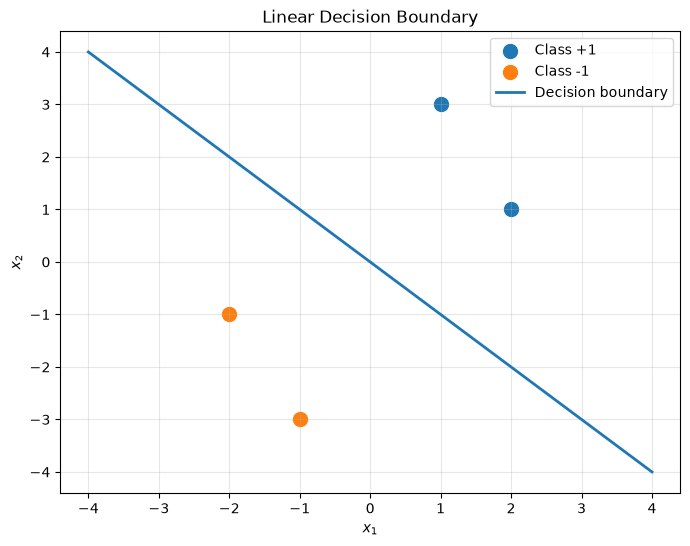

In [51]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [2, 1],
    [-2, -1],
    [1, 3],
    [-1, -3]
])

y = np.array([1, -1, 1, -1])

w = np.array([1.0, 1.0])
b = 0.0

plt.figure(figsize=(8, 6))

# Plot the two classes
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    s=100,
    label="Class +1"
)

plt.scatter(
    X[y == -1, 0],
    X[y == -1, 1],
    s=100,
    label="Class -1"
)

# Decision boundary:
# w1*x1 + w2*x2 + b = 0
x1 = np.linspace(-4, 4, 100)
x2 = -(w[0] * x1 + b) / w[1]

plt.plot(
    x1,
    x2,
    linewidth=2,
    label="Decision boundary"
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Linear Decision Boundary")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### What to Observe

The line represents:

$$
\vec{w}^{\,T}\vec{x}+b=0
$$

The two classes lie on opposite sides of this boundary.

The vector:

$$
\vec{w}
$$

is perpendicular to the decision boundary.

This visualization is possible because we are working in two dimensions.

For higher-dimensional data, the same mathematics still works even though we cannot directly draw the hyperplane.

## 21. Visualizing the Weight Vector

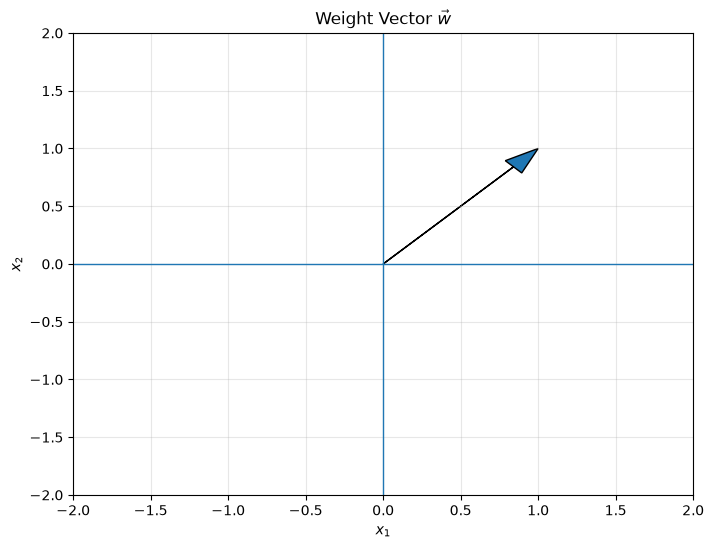

In [52]:
plt.figure(figsize=(8, 6))

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.arrow(
    0,
    0,
    w[0],
    w[1],
    head_width=0.15,
    length_includes_head=True
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Weight Vector $\\vec{w}$")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(alpha=0.3)

plt.show()

The weight vector:

$$
\vec{w}
$$

points in the normal direction to the decision boundary.

Therefore:

$$
\boxed{
\vec{w}
\perp
\text{decision boundary}
}
$$

This is the geometric meaning of the learned weight vector.

## 22. A Higher-Dimensional Example Without Visualization

Suppose we have a 10-dimensional feature vector:

$$
\vec{x}\in\mathbb{R}^{10}
$$

and:

$$
\vec{w}\in\mathbb{R}^{10}
$$

We cannot visualize the 10-dimensional hyperplane.

But NumPy has no difficulty representing the vectors.

We can still calculate:

$$
\vec{w}^{\,T}\vec{x}
$$

and:

$$
\|\vec{w}\|
$$

and therefore:

$$
\frac{
\vec{w}^{\,T}\vec{x}+b
}{
\|\vec{w}\|
}
$$

The computational operations are exactly the same.

Only the number of coordinates has increased.

## 23. NumPy Does Not Need to "Understand" the Geometry

This is an important distinction.

NumPy performs operations such as:

```python
np.dot(w, x)

and:

In [53]:
np.linalg.norm(w)

np.float64(1.4142135623730951)

It does not need to understand the concept of:

"decision boundary"

or:

"margin"

We provide the mathematical operations.

NumPy simply performs them efficiently.

The Machine Learning meaning comes from the mathematics we have developed.

Therefore:

$$ \boxed{ \text{Mathematics} \rightarrow \text{Algorithm} \rightarrow \text{NumPy implementation} } $$

Understanding this mapping is more important than memorizing individual NumPy functions.



## 24. The Complete Mathematical-to-NumPy Map

| Mathematical concept | Mathematics | NumPy |
|---|---|---|
| Feature vector | $\vec{x}$ | `x` |
| Weight vector | $\vec{w}$ | `w` |
| Bias | $b$ | `b` |
| Dot product | $\vec{w}^{\,T}\vec{x}$ | `np.dot(w, x)` |
| Classifier score | $\vec{w}^{\,T}\vec{x}+b$ | `np.dot(w, x) + b` |
| Prediction | $\operatorname{sign}(score)$ | `np.sign(score)` |
| Functional margin | $y(\vec{w}^{\,T}\vec{x}+b)$ | `y * score` |
| Weight norm | $\|\vec{w}\|$ | `np.linalg.norm(w)` |
| Geometric margin | $\dfrac{y(\vec{w}^{\,T}\vec{x}+b)}{\|\vec{w}\|}$ | `functional_margin / np.linalg.norm(w)` |

This table is worth remembering because it connects the mathematical notation directly to the code we will use later in Machine Learning.

## 25. ⭐ Final Mental Model

We can now translate the complete mathematical pipeline into Python.

The important idea is:

$$
\boxed{
\text{Mathematics}
\longleftrightarrow
\text{NumPy implementation}
}
$$

### 1. Feature Vector

Mathematics:

$$
\vec{x}
=
\begin{bmatrix}
2\\
3\\
4
\end{bmatrix}
$$

NumPy:

```python
x = np.array([2.0, 3.0, 4.0])

In [60]:

x = np.array([2.0, 3.0, 4.0])

print("x =", x)

x = [2. 3. 4.]


### 2. Weight Vector

Mathematics:

$$
\vec{w}
=
\begin{bmatrix}
1\\
-2\\
3
\end{bmatrix}
$$

NumPy:

```python
w = np.array([1.0, -2.0, 3.0])

In [61]:

w = np.array([1.0, -2.0, 3.0])

print("w =", w)

w = [ 1. -2.  3.]


### 3. Classifier Score

Mathematics:

$$
\vec{w}^{\,T}\vec{x}+b
$$

For our example:

$$
b=2
$$

NumPy:

```python
score = np.dot(w, x) + b

In [62]:

b = 2.0

score = np.dot(w, x) + b

print("Classifier score:", score)

Classifier score: 10.0


Classifier score: 10.0

### 4. Prediction

Mathematics:

$$
\hat{y}
=
\operatorname{sign}
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
$$

NumPy:

```python
prediction = np.sign(score)

In [63]:


prediction = np.sign(score)

print("Predicted class:", prediction)

Predicted class: 1.0


Predicted class: 1.0

### 5. Functional Margin

Mathematics:

$$
y
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
$$

For our example:

$$
y=+1
$$

NumPy:

```python
functional_margin = y * score

In [64]:

y = 1

functional_margin = y * score

print("Functional margin:", functional_margin)

Functional margin: 10.0


Functional margin: 10.0

### 6. Weight Vector Norm

Mathematics:

$$
\|\vec{w}\|
$$

NumPy:

```python
w_norm = np.linalg.norm(w)

In [65]:

w_norm = np.linalg.norm(w)

print("||w||:", w_norm)

||w||: 3.7416573867739413


||w||: 3.7416573867739413

### 7. Geometric Margin

Mathematics:

$$
\boxed{
\gamma
=
\frac{
y
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
}{
\|\vec{w}\|
}
}
$$

NumPy:

```python
geometric_margin = functional_margin / w_norm

In [66]:

geometric_margin = functional_margin / w_norm

print("Geometric margin:", geometric_margin)

Geometric margin: 2.6726124191242437


Geometric margin: 2.6726124191242437

### ⭐ The Complete Mathematical → NumPy Mapping

| Concept | Mathematics | NumPy |
|---|---|---|
| Feature vector | $\vec{x}$ | `x` |
| Weight vector | $\vec{w}$ | `w` |
| Bias | $b$ | `b` |
| Dot product | $\vec{w}^{\,T}\vec{x}$ | `np.dot(w, x)` |
| Classifier score | $\vec{w}^{\,T}\vec{x}+b$ | `np.dot(w, x) + b` |
| Prediction | $\operatorname{sign}(\vec{w}^{\,T}\vec{x}+b)$ | `np.sign(score)` |
| Functional margin | $y(\vec{w}^{\,T}\vec{x}+b)$ | `y * score` |
| Weight norm | $\|\vec{w}\|$ | `np.linalg.norm(w)` |
| Geometric margin | $\dfrac{y(\vec{w}^{\,T}\vec{x}+b)}{\|\vec{w}\|}$ | `functional_margin / w_norm` |

The complete pipeline is therefore:

$$
\vec{x}
\quad,\quad
\vec{w}
\quad,\quad
b
$$

$$↓$$

$$
\boxed{
\vec{w}^{\,T}\vec{x}+b
}
$$

$$↓$$

$$
\boxed{
y
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
}
$$

$$↓$$

$$
\boxed{
\frac{
y
\left(
\vec{w}^{\,T}\vec{x}+b
\right)
}{
\|\vec{w}\|
}
}
$$

$$↓$$

$$
\boxed{
\text{Geometric margin}
}
$$

And in NumPy:

```python
score = np.dot(w, x) + b

functional_margin = y * score

w_norm = np.linalg.norm(w)

geometric_margin = functional_margin / w_norm

> **The mathematics tells us what to calculate.**. 

> **NumPy gives us the tools to calculate it.**

---

## One more improvement I recommend

We don't actually need separate executable cells for every single mapping in the final mental model. We've **already executed and verified** each operation earlier in Part 15.

So I recommend that the final section contain:

1. **One conceptual Markdown mapping**
2. **One complete executable Code cell**
3. **One final interpretation**

That keeps the notebook professional rather than repetitive.

### 🟩 Final executable cell

In [68]:




import numpy as np

# Feature vector
x = np.array([2.0, 3.0, 4.0])

# Weight vector
w = np.array([1.0, -2.0, 3.0])

# Bias and class label
b = 2.0
y = 1

# Linear classifier score
score = np.dot(w, x) + b

# Prediction
prediction = np.sign(score)

# Functional margin
functional_margin = y * score

# Weight norm
w_norm = np.linalg.norm(w)

# Geometric margin
geometric_margin = functional_margin / w_norm

print("Classifier score:", score)
print("Predicted class:", prediction)
print("True class:", y)
print("Functional margin:", functional_margin)
print("||w||:", w_norm)
print("Geometric margin:", geometric_margin)

Classifier score: 10.0
Predicted class: 1.0
True class: 1
Functional margin: 10.0
||w||: 3.7416573867739413
Geometric margin: 2.6726124191242437


⚠️ Important notebook-quality rule going forward

I will be more strict about this from now on:

Markdown mathematical placeholders are okay:

$$ \vec{x}= \begin{bmatrix} x_1\\ x_2\\ \vdots\\ x_n \end{bmatrix} $$

Python placeholders such as this are NOT okay in Code cells:

x = np.array(...)

Instead, either use a real executable example:

x = np.array([2.0, 3.0, 4.0])

or keep it explicitly as a Markdown code snippet, not an executable Code cell.

Also, I will continue using the vector notation consistently:

$$ \boxed{\vec{x}},\qquad \boxed{\vec{w}},\qquad \boxed{\vec{w}^{\,T}\vec{x}} $$

rather than accidentally falling back to plain \(x\) and \(w\) when we are discussing vectors.

Your screenshot was therefore showing a genuine notebook error, not a problem with NumPy or Jupyter. The fix above removes it cleanly.